In [1]:
import sys
import os

# Adds the parent directory to the path
sys.path.append(os.path.abspath(".."))

In [8]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

raw_image = cv2.imread("../assets/white-circle.jpeg")
assert raw_image is not None
image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)

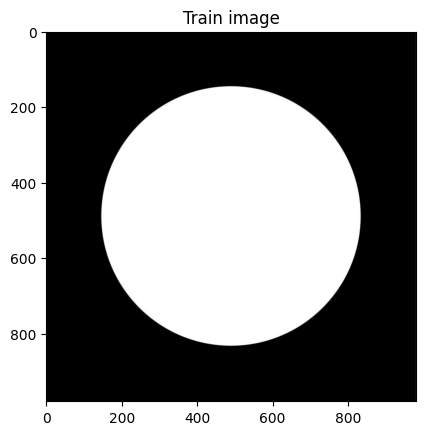

In [9]:
plt.imshow(image)
plt.title("Train image")
plt.show()

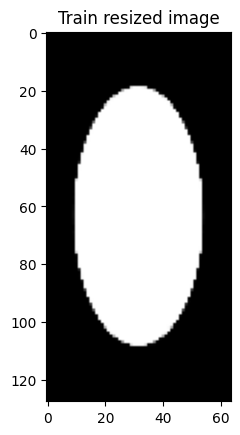

In [10]:
image_resized = cv2.resize(image, (64, 128))
plt.imshow(image_resized)
plt.title("Train resized image")
plt.show()

(128, 64)


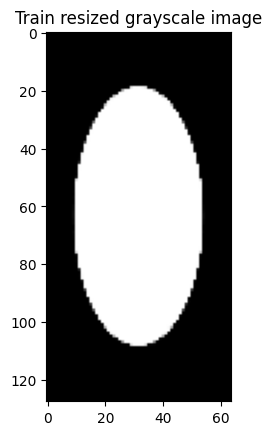

In [11]:
import numpy as np

image_grayscale = cv2.cvtColor(image_resized, cv2.COLOR_BGR2GRAY).astype(
    np.float64
)
print(image_grayscale.shape)

plt.imshow(image_grayscale, cmap="gray")
plt.title("Train resized grayscale image")
plt.show()

In [12]:
from src.shared.hog.sobel import compute_sobel
from src.shared.utils import cart_to_polar

gradient_x, gradient_y = compute_sobel(image_grayscale)
mag, angle = cart_to_polar(gradient_x, gradient_y, angle_in_degrees=True)

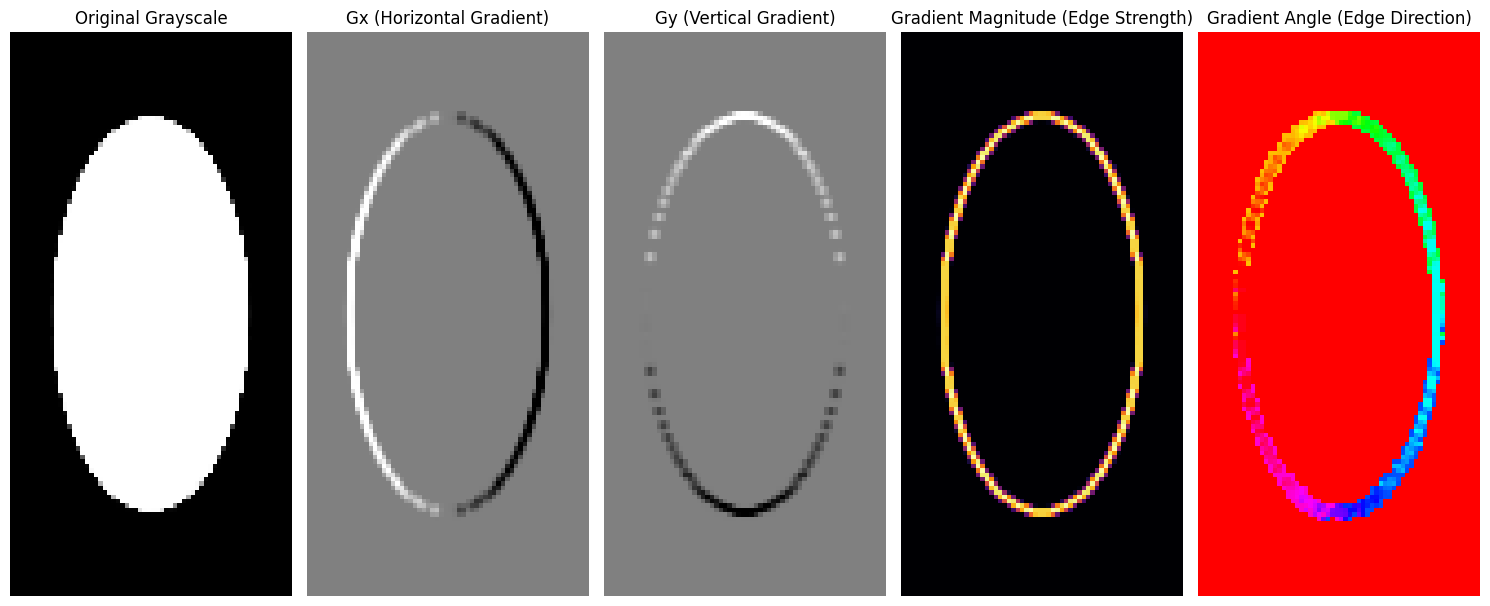

In [13]:
plt.figure(figsize=(15, 10))

# Original Image
plt.subplot(1, 5, 1)
plt.imshow(image_grayscale, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

# Horizontal Gradient (Gx) - Highlights vertical edges
plt.subplot(1, 5, 2)
plt.imshow(gradient_x, cmap="gray")
plt.title("Gx (Horizontal Gradient)")
plt.axis("off")

# Vertical Gradient (Gy) - Highlights horizontal edges
plt.subplot(1, 5, 3)
plt.imshow(gradient_y, cmap="gray")
plt.title("Gy (Vertical Gradient)")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(mag, cmap="inferno")
plt.title("Gradient Magnitude (Edge Strength)")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(angle, cmap="hsv")
plt.title("Gradient Angle (Edge Direction)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
cell_size = 8
nbins = 9
h, w = image_grayscale.shape
cell_h, cell_w = h // cell_size, w // cell_size
print(f"Cell size: ({cell_h}, {cell_w})")

Cell size: (16, 8)


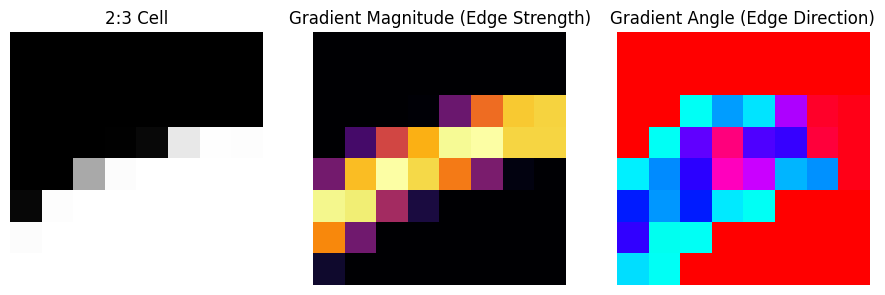

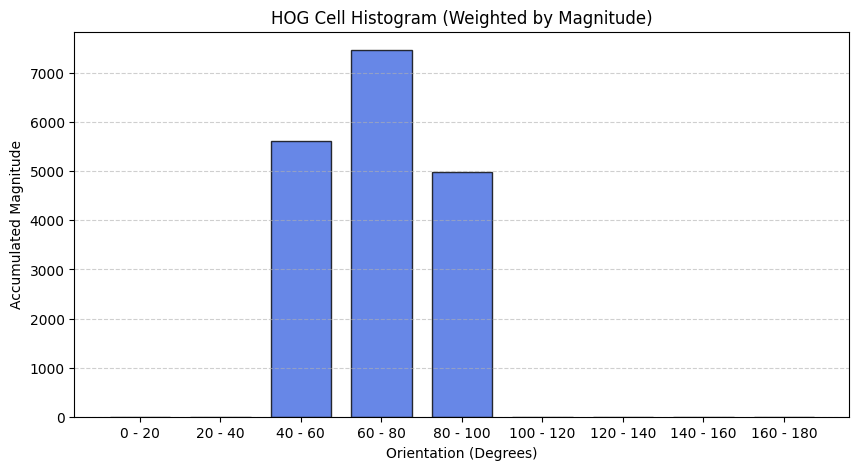

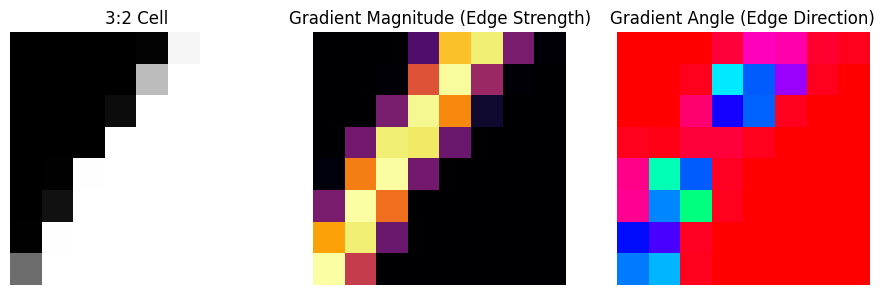

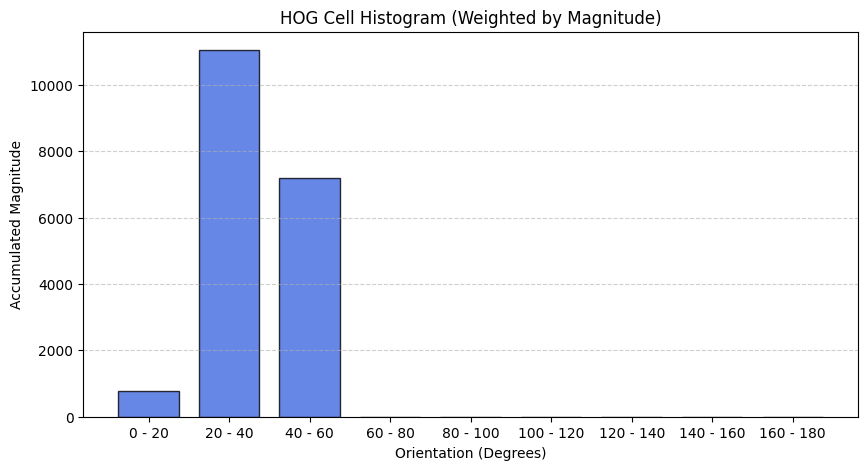

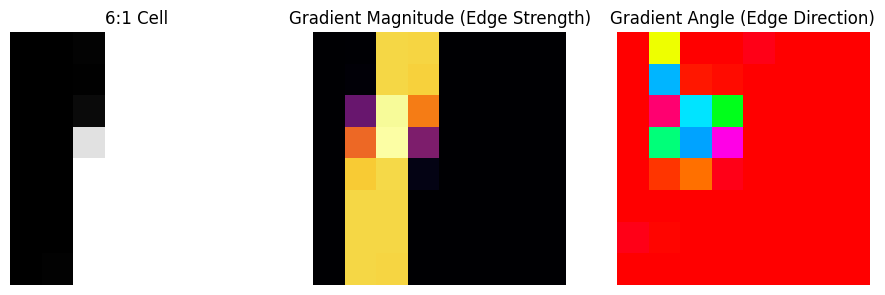

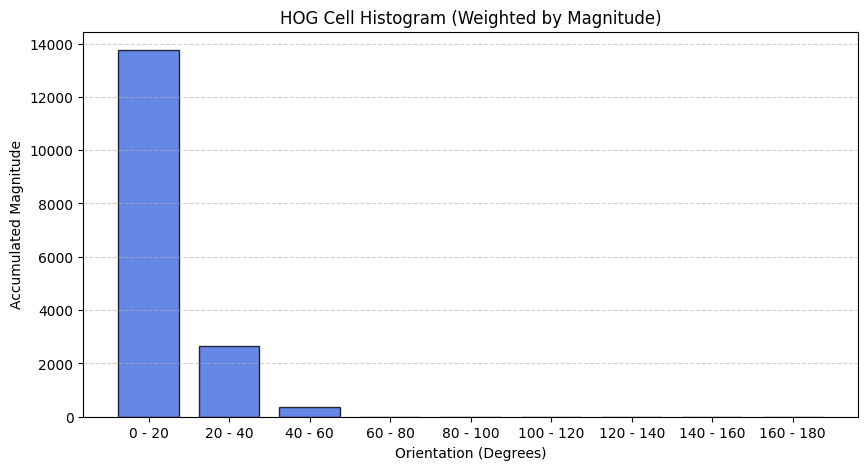

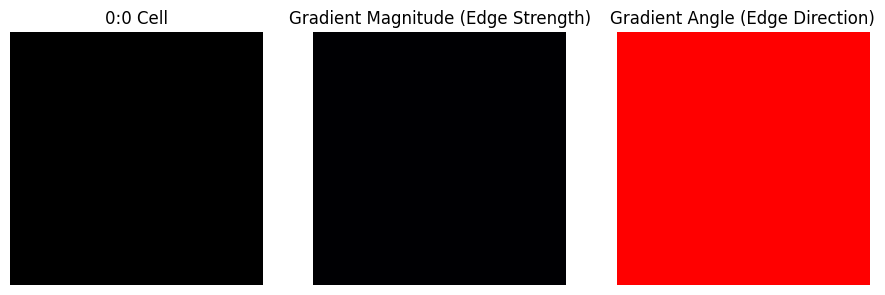

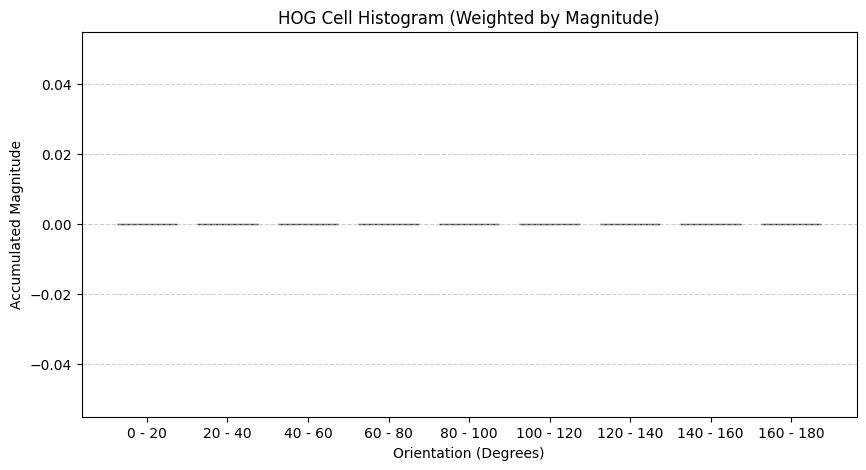

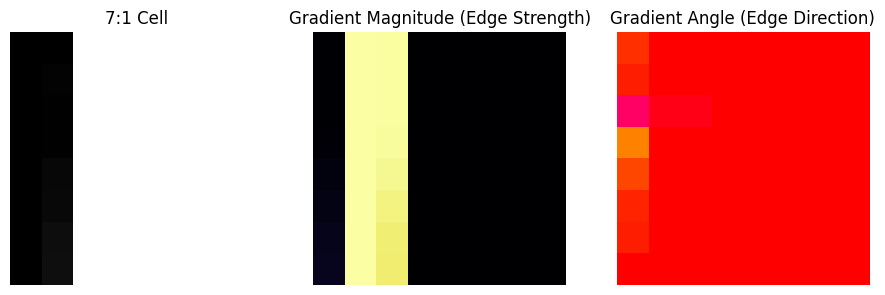

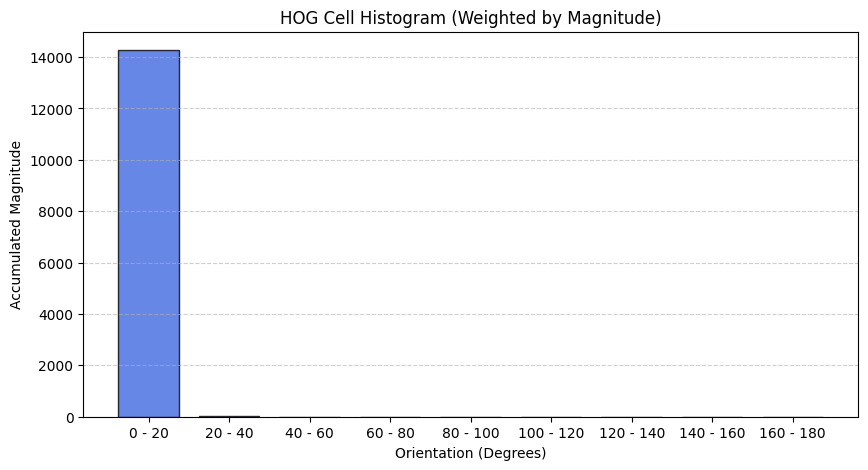

In [15]:
# Extract the 8x8 patch for magnitude and angle
indices = [(2, 3), (3, 2), (6, 1), (0, 0), (7, 1)]

for i, j in indices:
    mag_patch = mag[
        i * cell_size : (i + 1) * cell_size, j * cell_size : (j + 1) * cell_size
    ]
    angle_patch = angle[
        i * cell_size : (i + 1) * cell_size, j * cell_size : (j + 1) * cell_size
    ]

    plt.figure(figsize=(15, 10))

    plt.subplot(1, 4, 1)
    plt.imshow(
        image_grayscale[
            i * cell_size : (i + 1) * cell_size,
            j * cell_size : (j + 1) * cell_size,
        ],
        cmap="gray",
    )
    plt.title(f"{i}:{j} Cell")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(mag_patch, cmap="inferno")
    plt.title("Gradient Magnitude (Edge Strength)")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(angle_patch, cmap="hsv")
    plt.title("Gradient Angle (Edge Direction)")
    plt.axis("off")

    # Calculate histogram for this cell
    # Map 0-180 degrees into 9 bins (20 degrees per bin)
    hist, bin_edges = np.histogram(
        angle_patch, bins=nbins, range=(0, 180), weights=mag_patch
    )

    bin_labels = list(
        map(
            lambda batch: f"{int(batch[0])} - {int(batch[1])}",
            zip(bin_edges, bin_edges[1:]),
        )
    )
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    plt.figure(figsize=(10, 5))
    plt.bar(
        bin_centers,
        hist,
        width=15,
        color="royalblue",
        edgecolor="black",
        alpha=0.8,
    )

    plt.title("HOG Cell Histogram (Weighted by Magnitude)")
    plt.xlabel("Orientation (Degrees)")
    plt.ylabel("Accumulated Magnitude")
    plt.xticks(bin_centers, bin_labels)  # Set ticks to the center of each bin
    plt.grid(axis="y", linestyle="--", alpha=0.6)

    plt.show()

In [16]:
hog_cells = np.zeros((cell_h, cell_w, nbins))
for i in range(cell_h):
    for j in range(cell_w):
        mag_patch = mag[
            i * cell_size : (i + 1) * cell_size,
            j * cell_size : (j + 1) * cell_size,
        ]
        ang_patch = angle[
            i * cell_size : (i + 1) * cell_size,
            j * cell_size : (j + 1) * cell_size,
        ]

        # Calculate histogram for this cell
        # Map 0-180 degrees into 9 bins (20 degrees per bin)
        hist, _ = np.histogram(
            ang_patch, bins=nbins, range=(0, 180), weights=mag_patch
        )
        hog_cells[i, j, :] = hist

In [24]:
block_size = 2
hog_features = []

for i in range(cell_h - block_size + 1):
    for j in range(cell_w - block_size + 1):
        block = hog_cells[i : i + block_size, j : j + block_size].flatten()
        norm = np.sqrt(np.sum(block**2) + 1e-6)
        hog_features.append(block / norm)
final_hog_array = np.array(hog_features).flatten()